In [11]:
# ======================================================================
# SECTION: ADDITIVE AND MULTIPLICATIVE SYMMETRIC MATRICES
# COMPLEXITY: O(m * n^2) - Multiplicative method (M.T @ M) is the bottleneck.
# DATA SHAPE: Additive: (n x n) | Multiplicative: (m x n) -> (n x n) and (m x m)
# MATH: SymA = (A + A.T)/2 | MtM = M.T @ M | MMt = M @ M.T
# TOOLS: .T attribute, np.array_equal(), assert, np.random.rand()
# ======================================================================

import numpy as np
from sympy import *
import matplotlib.pyplot as plt

# set global print options
np.set_printoptions(suppress=True, precision=3)

### Additive and Multiplicative Symmetric Matrices

#### 1. The Additive Method (Square Matrices Only)
For any square matrix $A$, we can create a symmetric version by averaging the matrix with its transpose.$$S = \frac{1}{2}(A + A^T)$$
* Property: The result is always symmetric.
* Constraint: $A$ must be square ($n \times n$).

#### 2. The Multiplicative Method (The "Gram Matrix")
For any matrix $M$ (even rectangular $m \times n$), multiplying the matrix by its transpose results in a symmetric matrix.
* $M^T M$: Results in a square symmetric matrix of size $(n \times n)$.
* $M M^T$: Results in a square symmetric matrix of size $(m \times m)$.

In [15]:
## additive method

# create matrices
n = 4

A = np.round(10*np.random.rand(n, n), )
SymA = (A + A.T) / 2

print(f"Is Matrix Symmetric? {np.array_equal(SymA, SymA.T)}\n")

## multiplicative method

# create matrices
m = 6
n = 4

M = np.random.rand(m, n)
MtM = M.T @ M
MMt = M @ M.T

# confirm each matrix is square
assert MtM.shape == (M.shape[1], M.shape[1])
assert MMt.shape == (M.shape[0], M.shape[0])

print(f"Is M.T @ M square? {MtM.shape[0] == MtM.shape[1]}")
print(f"Is M @ M.T square? {MMt.shape[0] == MMt.shape[1]}\n")

# confirm matrices are symmetric
assert np.array_equal(MtM, MtM.T)
assert np.array_equal(MMt, MMt.T)

print(f"Is M.T @ M symmetric? {np.array_equal(MtM, MtM.T)}")
print(f"Is M @ M.T symmetric? {np.array_equal(MMt, MMt.T)}")


Is Matrix Symmetric? True

Is M.T @ M square? True
Is M @ M.T square? True

Is M.T @ M symmetric? True
Is M @ M.T symmetric? True


### Code Challenge: symmetry of combined symmetric matrices

In [26]:
# ======================================================================
# SECTION: SYMMETRY OF COMBINED SYMMETRIC MATRICES
# COMPLEXITY: O(m^3) - Standard Product (left @ right) is the bottleneck.
# DATA SHAPE: Left (m x m) and Right (m x m) -> Output (m x m)
# MATH: (A+B).T = A+B | (A*B).T = A*B | (AB).T = B^T A^T = BA
# TOOLS: np.random.seed(), np.array_equal(), @ operator, * operator
# ======================================================================

# create two symmetric matrices
m = 4  # matrix dimension

# reproducible random matrices
np.random.seed(42)

B = np.random.randint(-10, 11, size=(m, m))
SymB = B.T @ B
C = np.random.randint(-10, 11, size=(m, m))
SymC = C.T @ C


def matrices_are_equal_to_transpose(matrix: np.ndarray) -> bool:
    """Return True if the matrix is exactly equal to its transpose."""
    return np.array_equal(matrix, matrix.T)


def is_symmetric(symmetric_matrix: np.ndarray) -> bool:
    """Return True if the matrix is exactly symmetric."""
    return matrices_are_equal_to_transpose(symmetric_matrix)


def assert_symmetric_matrix(symmetric_matrix: np.ndarray, name: str) -> None:
    """Ensure a matrix is symmetric before performing operations."""
    assert matrices_are_equal_to_transpose(symmetric_matrix), (
        f"{name} must be symmetric before performing operations, but {name}.shape={symmetric_matrix.shape} "
        f"and {name}.T.shape={symmetric_matrix.T.shape}."
    )


def assert_same_shape(left: np.ndarray, right: np.ndarray, left_name: str, right_name: str) -> None:
    """Ensure two matrices have matching shapes before combining them."""
    assert left.shape == right.shape, (
        f"{left_name} and {right_name} must have the same dimensions before performing operations, "
        f"but {left_name}.shape={left.shape} and {right_name}.shape={right.shape}."
    )


class MatrixOperationKey:
    SUM = "S"
    PRODUCT = "T"
    HADAMARD = "H"


def compute_matrix_operations(left: np.ndarray, right: np.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Compute sum, standard product, and Hadamard product for two matrices."""
    return left + right, left @ right, left * right


def assert_symmetric_and_same_shape(left: np.ndarray, right: np.ndarray, left_name: str, right_name: str) -> None:
    """Ensure both matrices are symmetric and have matching shapes before performing operations."""
    assert_symmetric_matrix(left, left_name)
    assert_symmetric_matrix(right, right_name)
    assert_same_shape(left, right, left_name, right_name)


# validate inputs before combining them
assert_symmetric_and_same_shape(SymB, SymC, "SymB", "SymC")

# compute sum, product, and Hadamard product
S, T, H = compute_matrix_operations(SymB, SymC)
# Matrix multiplication of symmetric matrices is not generally symmetric.
# It is symmetric only if the matrices commute.
# In general, (SymB @ SymC).T = SymC @ SymB.

# print matrices
for index, (label, matrix_value) in enumerate([
    ("SymB", SymB),
    ("SymC", SymC),
    ("S = SymB + SymC", S),
    ("T = SymB @ SymC", T),
    ("H = SymB * SymC", H),
]):
    if index:
        print()
    print(f"{label}:\n", np.array2string(matrix_value, precision=2, suppress_small=True))

# check symmetry of each result
for label, matrix_value in [("sum", S), ("multiplication", T), ("Hadamard product", H)]:
    print(f"\nIs the {label} result symmetric? {is_symmetric(matrix_value)}")


SymB:
 [[  34  -42  -34    3]
 [ -42  245  -84  152]
 [ -34  -84  232 -192]
 [   3  152 -192  194]]

SymC:
 [[ 166  -12   49 -118]
 [ -12   52   75  -32]
 [  49   75  179 -140]
 [-118  -32 -140  216]]

S = SymB + SymC:
 [[ 200  -54   15 -115]
 [ -54  297   -9  120]
 [  15   -9  411 -332]
 [-115  120 -332  410]]

T = SymB @ SymC:
 [[  4128  -5238  -7990   2740]
 [-31964   2080 -19999  41708]
 [ 29388  19584  60442 -67252]
 [-33626 -12740 -49981  63566]]

H = SymB * SymC:
 [[ 5644   504 -1666  -354]
 [  504 12740 -6300 -4864]
 [-1666 -6300 41528 26880]
 [ -354 -4864 26880 41904]]

Is the sum result symmetric? True

Is the multiplication result symmetric? False

Is the Hadamard product result symmetric? True


### Multiplication of two symmetric matrices

#### 1. The Symmetry Property
A matrix $S$ is symmetric if $S = S^T$.
When multiplying two symmetric matrices $A$ and $B$:$(AB)^T = B^T A^T$
Since $A$ and $B$ are symmetric, this becomes: $(AB)^T = BA$

#### 2. The Commutativity Constraint
The product $AB$ is symmetric only if $A$ and $B$ commute ($AB = BA$).
* If $AB = BA$, then $(AB)^T = AB$ (Symmetric).
* If $AB \neq BA$, then $(AB)^T \neq AB$ (Non-Symmetric).

#### 5. Symbolic Verification
By defining matrices $D$ and $E$ with unique symbols and checking $DE - (DE)^T$:
* If the result is a zero matrix, the product is symmetric.
* If the result contains non-zero symbolic expressions, the product is not symmetric.

In [43]:
# ======================================================================
# SECTION: MULTIPLICATION OF SYMMETRIC MATRICES (SYMBOLIC PROOF)
# COMPLEXITY: O(n^3) - Symbolic matrix multiplication.
# DATA SHAPE: D (4x4) @ E (4x4) -> Output (4x4)
# MATH: (DE).T = E.T @ D.T = ED. Therefore, DE is symmetric iff DE = ED.
# TOOLS: sympy.symbols, sympy.Matrix, .T attribute, init_printing()
# ======================================================================

a,b,c,d,e,f,g,h,k,l,m,n,o,p,q,r,s,t,u = symbols('a b c d e f g h k l m n o p q r s t u', real=True)

# symmetric and constant-diagonal matrices
D = Matrix([ [a,b,c,d],
             [b,a,e,f],
             [c,e,a,g],
             [d,f,g,a] ])

E = Matrix([ [h,k,l,m],
             [k,h,n,o],
             [l,n,h,p],
             [m,o,p,h] ])

assert D == D.T
assert E == E.T

init_printing()

D@E - (D@E).T # multiplying symmetric matrices does not result in a symmetric matrix

⎡          0             c⋅n + d⋅o - e⋅l - f⋅m   b⋅n + d⋅p - e⋅k - g⋅m   b⋅o + ↪
⎢                                                                              ↪
⎢-c⋅n - d⋅o + e⋅l + f⋅m            0             b⋅l - c⋅k + f⋅p - g⋅o   b⋅m - ↪
⎢                                                                              ↪
⎢-b⋅n - d⋅p + e⋅k + g⋅m  -b⋅l + c⋅k - f⋅p + g⋅o            0             c⋅m - ↪
⎢                                                                              ↪
⎣-b⋅o - c⋅p + f⋅k + g⋅l  -b⋅m + d⋅k - e⋅p + g⋅n  -c⋅m + d⋅l - e⋅o + f⋅n        ↪

↪  c⋅p - f⋅k - g⋅l⎤
↪                 ⎥
↪  d⋅k + e⋅p - g⋅n⎥
↪                 ⎥
↪  d⋅l + e⋅o - f⋅n⎥
↪                 ⎥
↪      0          ⎦

In [44]:
init_printing()

n = 2
D1 = D[ 0:n, 0:n ]
E1 = E[ 0:n, 0:n]

D1@E1 - (D1@E1).T # for a 2x2 matrix, the result is symmetric

⎡0  0⎤
⎢    ⎥
⎣0  0⎦

### Code Challenge: The Matrix Asymmetry Index
1. Implement the matrix asymmetry index in code.
2. Test on symmetrix matrix, skew-symmetric matrix, random matrix.
3. Develop formula that will proportionally mix a symmetric and skew-symmetric matrix.
4. Confirm that the formula works using random matrices.

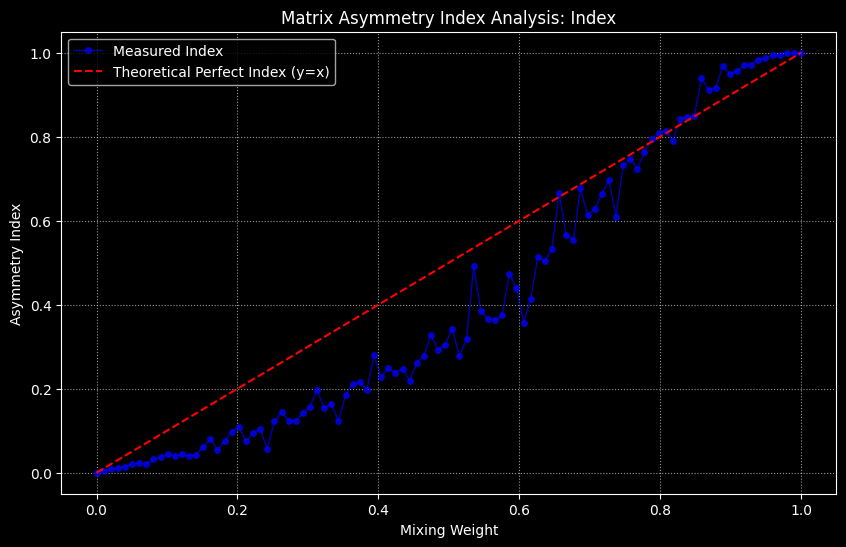

In [32]:
# ======================================================================
# SECTION: [EMPIRICAL MATRIX ASYMMETRY INDEX SIMULATION]
# COMPLEXITY: O(k * n^2) - Where k=100 (weight steps) and n=7 (matrix size).
# DATA SHAPE: Random Matrix(7, 7) -> Index Vector(100,).
# MATH: A = S + K (Decomposition) | a_i = ||A_mixed_skew|| / ||A_mixed||.
# TOOLS: np.random.randn(), np.linalg.norm(ord='fro'), np.allclose(), plt.grid()
# ======================================================================

def sum_check(matrix, symmetric_matrix, skew_symmetric_matrix):
    """Check the sum of symmetric and skew-symmetric matrices equals the original matrix."""
    return np.allclose(matrix, symmetric_matrix + skew_symmetric_matrix)


def calculate_norm(matrix: np.ndarray) -> float:
    """Calculate the Frobenius norm of a matrix."""
    return np.linalg.norm(matrix, ord='fro')


def plot_matrix(index, matrix: np.ndarray, title: str = ""):
    plt.figure(figsize=(10, 6))
    plt.plot(index, matrix, 'bo-', label='Measured Index', markersize=4, linewidth=1, alpha=0.7)
    plt.plot([0,1], [0,1], 'r--', label='Theoretical Perfect Index (y=x)', linewidth=1.5)
    plt.xlabel('Mixing Weight')
    plt.ylabel('Asymmetry Index')
    plt.title(f"Matrix Asymmetry Index Analysis: {title}")
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend()
    plt.show()

# generate a random square matrix
np.random.seed(40)
matrix_size = 7

# proportional formula: matrix_mixed = (1 - weight) * symmetric_matrix + weight * skew-symmetric_matrix
weight = np.linspace(0, 1, 100)
index = np.zeros_like(weight, dtype=float)

for i, weights in enumerate(weight):
    # generate random symmetric and skew-symmetric matrices
    matrix = np.random.rand(matrix_size, matrix_size)
    symmetric_matrix = (matrix + matrix.T) / 2
    skew_symmetric_matrix = (matrix - matrix.T) / 2

    if not sum_check(matrix, symmetric_matrix, skew_symmetric_matrix):
        raise ValueError("The sum of symmetric and skew-symmetric matrices does not equal the original matrix.")

    matrix_mixed = (1 - weights) * symmetric_matrix + weights * skew_symmetric_matrix
    matrix_mixed_skew = (matrix_mixed - matrix_mixed.T) / 2
    index[i] = calculate_norm(matrix_mixed_skew) / calculate_norm(matrix_mixed)

plot_matrix(weight, index, "Index")